# Merging travel time matrices

This notebook presents three features of the library relating to merging
different `TravelTimeMatrices` objects (or the destinations within a single
object). For each feature, a realistic use case is presented, pertaining to the
city of Santiago, Chile.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
from copy import deepcopy
import datetime
from pathlib import Path

import geopandas as gpd
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca, TwoStepFca
from xmin import travel_time

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # non-processed data
PRE_DATA_PATH = Path("../../data/processed")  # pre-processed data
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSUS_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_HEALTH_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
AMENITY_GREEN_PATH = PRE_DATA_PATH / "amenities" / "areas_verdes.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"
GTFS_SANTIAGO_PATH = PRE_DATA_PATH / "gtfs" / "Santiago.zip"

## Orígenes y destinos

In [ ]:
urban_boundaries_full = gpd.read_file(
    CENSUS_PATH,
    layer="Limite_Urbano_CPV24",
)

# we only filter boundaries corresponding to Valparaíso
urban_boundaries = urban_boundaries_full[
    (urban_boundaries_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# we get the convex hull to extract POIs and road network
boundaries_hull = urban_boundaries.union_all().convex_hull

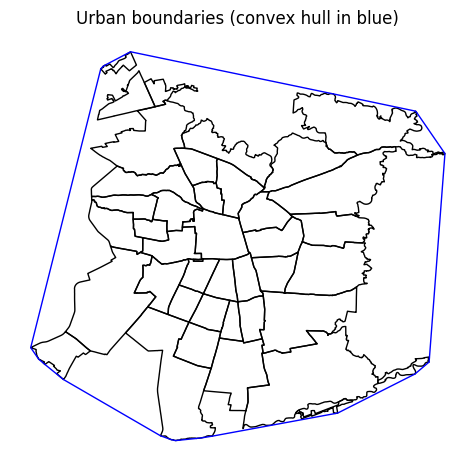

In [ ]:
ax = urban_boundaries.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([boundaries_hull]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Urban boundaries (convex hull in blue)")
plt.tight_layout()

In [9]:
city_blocks = gpd.read_file(
    CENSUS_PATH,
    layer="Manzanas_CPV24",
    mask=urban_boundaries.union_all(),
    use_arrow=True
)

Instead of generating a single origin grid, we generate three: one for the
young population, one for the older population, and one combining both.

In [10]:
origins_young = xmin.Origins.create_grid(
    regions=urban_boundaries,
    h3_resolution=9,
    population_gdf=city_blocks.assign(
        population=city_blocks["n_edad_18_24"]
        + city_blocks["n_edad_25_44"]
        + city_blocks["n_edad_45_59"]
    ),
)

origins_old = xmin.Origins.create_grid(
    regions=urban_boundaries,
    h3_resolution=9,
    population_gdf=city_blocks.rename(columns={"n_edad_60_mas": "population"}),
)

origins_full = xmin.Origins.create_grid(
    regions=urban_boundaries,
    h3_resolution=9,
    population_gdf=city_blocks.assign(
        population=city_blocks["n_edad_18_24"]
        + city_blocks["n_edad_25_44"]
        + city_blocks["n_edad_45_59"]
        + city_blocks["n_edad_60_mas"]
    ),
)

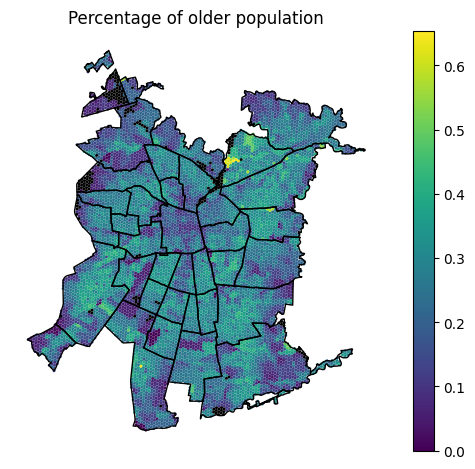

In [13]:
origins_comp = (
    origins_young.h3_grid.set_index("id")
    .rename(columns={"population": "population_young"})
    .assign(
        population_old=origins_old.h3_grid.set_index("id")["population"],
        pct_old=lambda gdf: gdf["population_old"]
        / (gdf["population_old"] + gdf["population_young"]),
    )
)
ax = origins_comp.plot(
    "pct_old", legend=True, missing_kwds={"color": "black"}
)
urban_boundaries.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title("Percentage of older population")
plt.tight_layout()

In [14]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=boundaries_hull
    )

In [ ]:
pharmacies = xmin.Amenity.from_osm(
    name="pharmacies",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)

In [16]:
health_gdf = gpd.read_file(AMENITY_HEALTH_PATH, mask=boundaries_hull)

health = xmin.Amenity(
    name="health",
    amenity_gdf=health_gdf[health_gdf["TIPO"].isin(["Hospital", "Clínica"])]
)

In [17]:
green_gdf = gpd.read_file(
    AMENITY_GREEN_PATH, layer="puntos", mask=boundaries_hull
)

parks = xmin.Amenity(
    name="parks", amenity_gdf=green_gdf[green_gdf["TIPO_EP"] == "PARQUE"]
)

## Caso 1: differentiated analysis according to age group (`merge_populations`)

One area of study within the 15-minute city concept is how to include people
with reduced mobility in the analysis. We would like to obtain accessibility
indices for a person with a lower walking speed, and compare it with the
accessibility for a person with an average walking speed.

If the accessibility function used does not consider supply and demand, this is
straightforward: because the accessibility in each cell depends solely on the
travel times from the cell in question, it is enough to reduce the walking
speed of all cells when calculating the TTMs in order to calculate the
accessibility considering a lower speed.

However, when using accessibility functions that do consider supply and demand,
assuming everyone is walking at a lower speed is not realistic, because the
accessibility of a cell will depend on the travel times for nearby cells (that
compete for access to the same destinations), and we know that most people in
each cell do not have reduced mobility. Thus, we would like to calculate, for
each cell, two accessibility scores: one for people with a lower walking speed,
and one for people with an average walking speed. These two indices must be
calculated **at the same time**, to reflect the competition that exists in real
life between these groups of people when accessing services.

### TTM calculation

Firstly, we calculate travel times separately for young people (between 16 and
59 years of age, assuming a walking speed of 3.6km/h) and for older people (60
or more years of age, assuming a walking speed of 2.4km/h).

In [18]:
ttms_young = xmin.TravelTimeMatrices.compute(
    origins=origins_young,
    amenities=[pharmacies],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    speed_walking=3.6
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [19]:
ttms_old = xmin.TravelTimeMatrices.compute(
    origins=origins_old,
    amenities=[pharmacies],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    speed_walking=2.4
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

We merge both results, obtaining a large TTM with travel times for each group.

In [20]:
ttms_merged = travel_time.merge_populations(
    {"young": ttms_young, "old": ttms_old}
)

In [21]:
ttms_merged.matrices["pharmacies"]

,from_id,to_id,travel_time
0,young/89b2c50b27bffff,pharmacies/node/12484237140,33.0
1,young/89b2c50b27bffff,pharmacies/way/447599096,10.0
2,young/89b2c50b27bffff,pharmacies/way/446603668,2.0
3,young/89b2c50b27bffff,pharmacies/node/678963208,29.0
4,young/89b2c50b27bffff,pharmacies/node/4445009204,20.0
...,...,...,...
34964,old/89b2c556b2bffff,pharmacies/node/11516987455,21.0
34965,old/89b2c556b2bffff,pharmacies/node/987506756,26.0
34966,old/89b2c556b2bffff,pharmacies/way/172600918,31.0
34967,old/89b2c556b2bffff,pharmacies/way/299943443,28.0


We also generate two extra objects: one assuming that the entire population
walks at a young person's speed, and one assuming that the entire population
walks at an older person's speed. These will be used to compare the naïve
approach (assuming all people travel at the same speed) with the new "combined"
approach.

In [22]:
ttms_all_young = xmin.TravelTimeMatrices(
    origins=origins_full,
    amenities=ttms_young.amenities.values(),
    matrices=ttms_young.matrices,
)

ttms_all_old = xmin.TravelTimeMatrices(
    origins=origins_full,
    amenities=ttms_old.amenities.values(),
    matrices=ttms_old.matrices,
)

### Index calculation

We use the same index function for all three TTMs.

In [24]:
e2sfca_pharmacies = EnhancedTwoStepFca(
    catchment_areas=[
        (0, 10, 1.00),
        (10, 20, 0.42),
        (20, 30, 0.03),
    ],
    desired_ratio=3_000,
)

In [25]:
acc_all_young = xmin.AccessibilityRatings.compute(
    ttms_all_young,
    index_function=e2sfca_pharmacies
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [26]:
acc_all_old = xmin.AccessibilityRatings.compute(
    ttms_all_old,
    index_function=e2sfca_pharmacies
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [27]:
acc_combined = xmin.AccessibilityRatings.compute(
    ttms_merged,
    index_function=e2sfca_pharmacies
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

We split the combined scores, between those obtained for younger people and
those obtained for older people.

In [28]:
split_accs = acc_combined.split()

In [29]:
acc_combined_young = split_accs["young"]
acc_combined_old = split_accs["old"]

### Visualizations

We notice that, when comparing the two naïve indices (assuming everyone walks at the same speed), there are many more origins with good accessibility scores if people walk faster; this is expected. However, when comparing the combined approach with the naïve one for each age group, younger people don't see major differences in their scores (and the differences that do exist are positive), while older people are affected negatively (and in a disproportionate manner) in certain areas.

This is because younger people can visit destinations which are much farther away without a big increase in travel time, a luxury people with reduced mobility cannot afford. It is important to be able to quantify the difference in accessibility between these groups, and mitigate it whenever possible with actions that compensate for lower accessibility (such as priority service for people with reduced mobility).

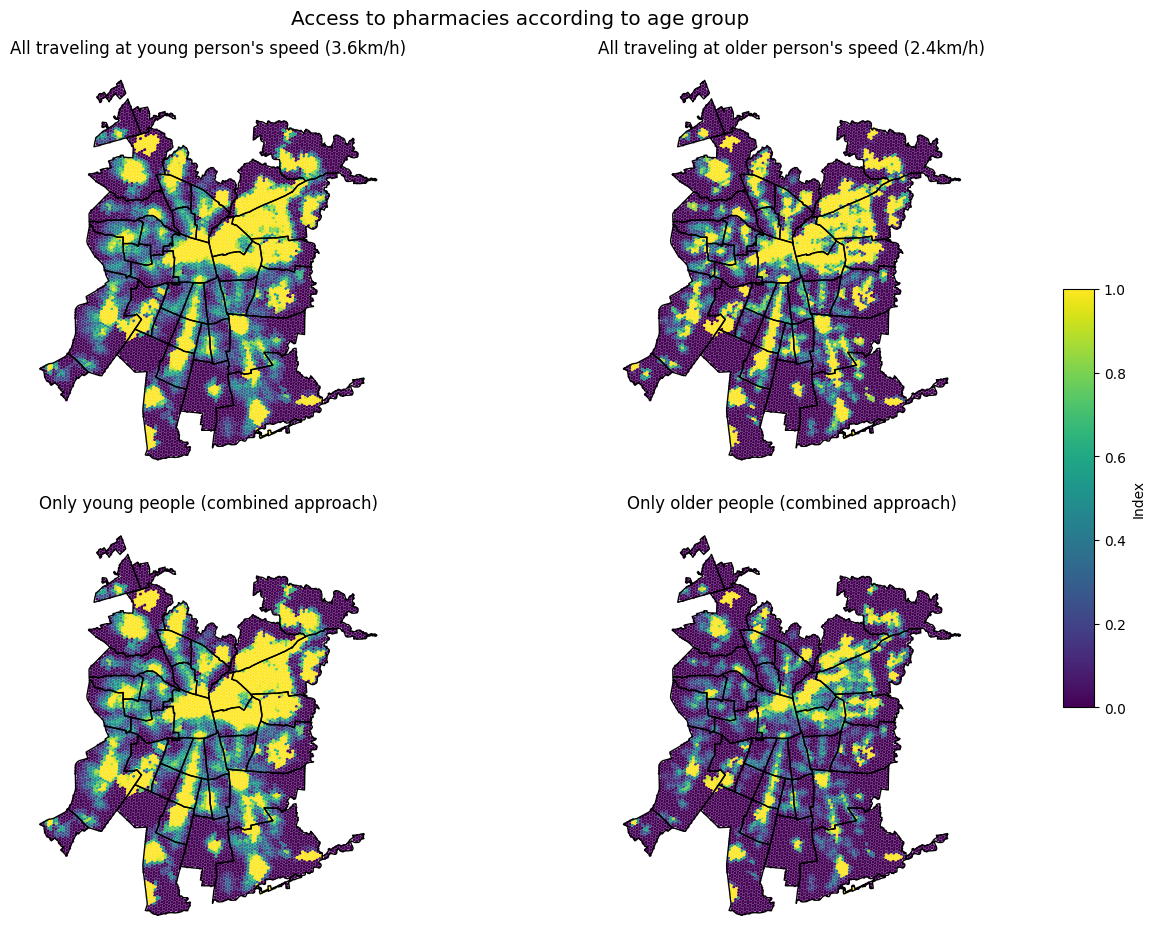

In [32]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_all_young = fig.add_subplot(gs[0:2, 0])
ax_all_old = fig.add_subplot(gs[0:2, 1])
ax_combined_young = fig.add_subplot(gs[2:4, 0])
ax_combined_old = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

for ax, acc, name in zip(
    (ax_all_young, ax_all_old, ax_combined_young, ax_combined_old),
    (acc_all_young, acc_all_old, acc_combined_young, acc_combined_old),
    (
        "All traveling at young person's speed (3.6km/h)",
        "All traveling at older person's speed (2.4km/h)",
        "Only young people (combined approach)",
        "Only older people (combined approach)"
    ),
):
    acc.visualize.choropleth("pharmacies", ax=ax)
    ax.set_axis_off()
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Index")

fig.suptitle(
    "Access to pharmacies according to age group",
    fontsize="x-large",
)

plt.tight_layout()

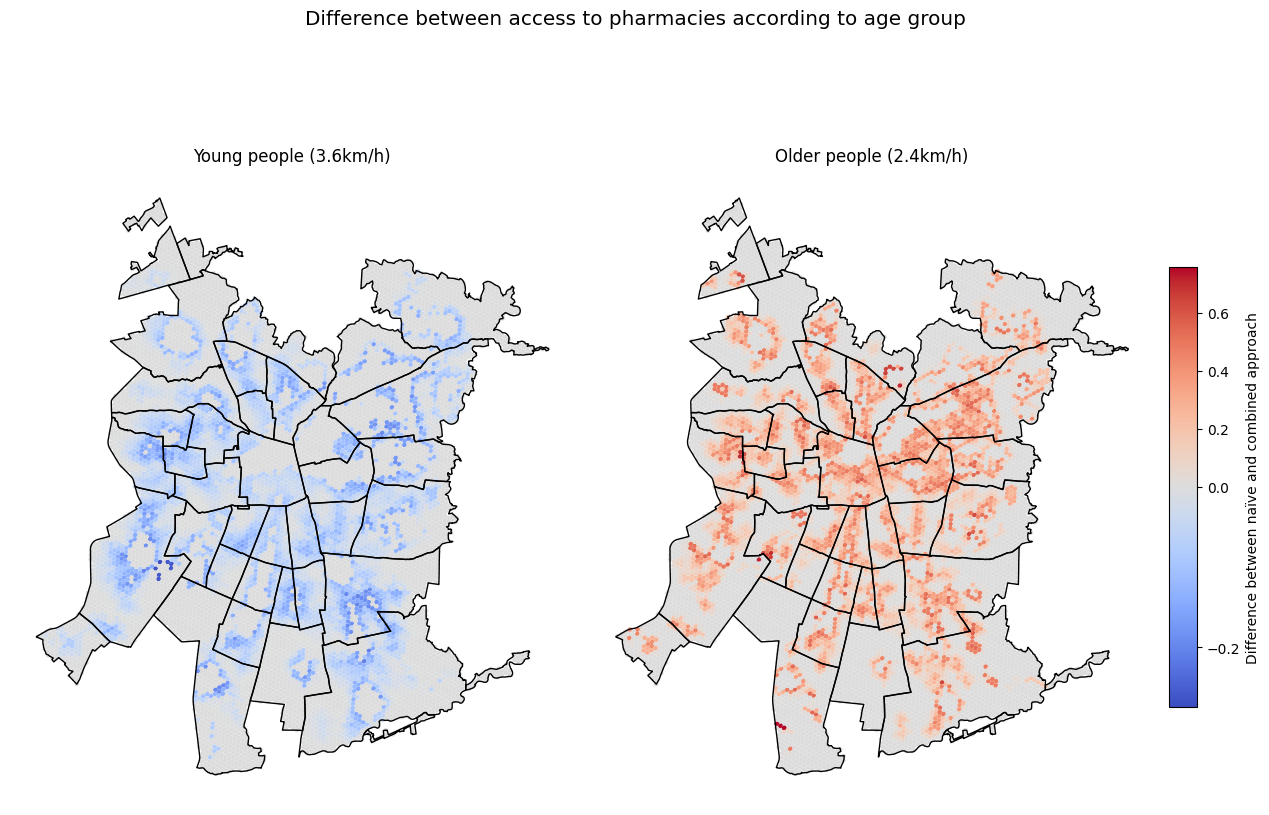

In [33]:
cmap = "coolwarm"

fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_diff_young = fig.add_subplot(gs[0:4, 0])
ax_diff_old = fig.add_subplot(gs[0:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

diff_young = acc_all_young.gdf["pharmacies"] - acc_combined_young.gdf["pharmacies"]
diff_old = acc_all_old.gdf["pharmacies"] - acc_combined_old.gdf["pharmacies"]

norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=diff_young.min(), vmax=diff_old.max())

acc_all_young.visualize.choropleth(diff_young, cmap=cmap, ax=ax_diff_young, norm=norm)
ax_diff_young.set_axis_off()
ax_diff_young.set_title("Young people (3.6km/h)")

acc_all_old.visualize.choropleth(diff_old, cmap=cmap, ax=ax_diff_old, norm=norm)
ax_diff_old.set_axis_off()
ax_diff_old.set_title("Older people (2.4km/h)")

cbar = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Difference between naïve and combined approach")

fig.suptitle(
    "Difference between access to pharmacies according to age group",
    fontsize="x-large",
)

plt.tight_layout()

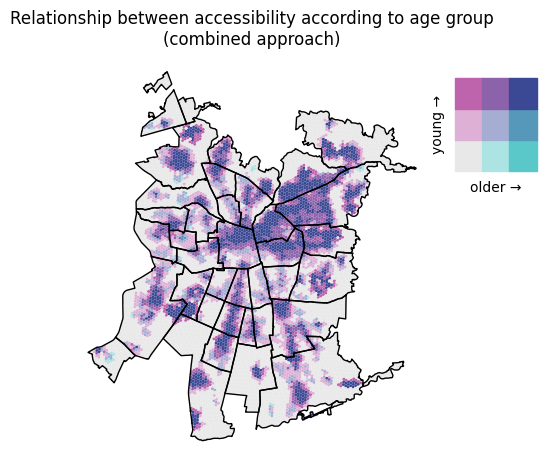

In [34]:
from mapclassify.classifiers import NaturalBreaks

ax = acc_combined_old.visualize.bivariate_choropleth(
    acc_combined_young.gdf["pharmacies"].rename("young"),
    acc_combined_old.gdf["pharmacies"].rename("older"),
    classifier=NaturalBreaks,
)
ax.set_axis_off()
ax.set_title(
    "Relationship between accessibility according to age group\n"
    "(combined approach)"
)

plt.tight_layout()

## Caso 2: calculation of TTMs with different parameters for different amenity types (`merge_amenities`)

`TravelTimeMatrices.compute()` generate travel time matrices from a given
origin grid to destinations in (potentially) multiple different amenity
categories, with the restriction that all amenity categories must use the same
parameters when calculating their TTM. If we wish to combine different amenity
types with different parameters, we can create two separate
`TravelTimeMatrices` objects and combine them using `merge_amenities`.

In this example, we calculate travel times to pharmacies using only walking as
a transport mode, and travel times to hospitals and clinics using walking and
public transport (because they are a less local service than pharmacies).

### TTM calculation

We calculate the matrices separately, and then combine them.

In [35]:
ttm_walk = xmin.TravelTimeMatrices.compute(
    origins=origins_full,
    amenities=[pharmacies],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [36]:
ttm_transit = xmin.TravelTimeMatrices.compute(
    origins=origins_full,
    amenities=[health],
    gtfs_paths=GTFS_SANTIAGO_PATH,
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=60),
    transport_modes=["WALK", "TRANSIT"],    
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

In [37]:
ttms_merged = travel_time.merge_amenities([ttm_walk, ttm_transit])

We observe that the combined object stores the matrices for both amenity types,
with the correct travel times.

In [39]:
ttms_merged.matrices["pharmacies"].equals(ttm_walk.matrices["pharmacies"])

True

In [40]:
ttms_merged.matrices["health"].equals(ttm_transit.matrices["health"])

True

### Index calculation

We use E2SFCA for both amenity types, but with different parameters (reflecting
the fact that pharmacies are a more local service, and have a lower capacity).

In [41]:
e2sfca_health = EnhancedTwoStepFca(
    catchment_areas=[
        (0, 20, 1.00),
        (20, 40, 0.42),
        (40, 60, 0.03),
    ],
    desired_ratio=20_000,
)

In [42]:
acc = xmin.AccessibilityRatings.compute(
    ttms_merged,
    index_function={
        "pharmacies": e2sfca_pharmacies,
        "health": e2sfca_health
    }
)

Calculando índices para cada necesidad...


  0%|          | 0/2 [00:00<?, ?it/s]

### Visualizations

The combined index was calculated as expected, with no issues. We can observe
the impact of public transport in the accessibility to health establishments,
particularly in communes such as Recoleta, San Miguel or La Cisterna, where
higher accessibility areas coincide with the locations of Metro stations (Line
2 in this case). A similar behavior can be seen in other communes with major
thoroughfares where Metro lines or multiple bus routes exist, such as Vicuña
Mackenna and Av. La Florida in La Florida, or Av. Independencia in
Independencia and Recoleta.

There is a clear tendency towards centralization in terms of accessibility to
hospitals and clinics, focused on the central and eastern districts of the city
(even in areas with low accessibility to pharmacies). On the other hand, the
southwestern and northwestern areas of the city aren't able to reach high
accessibility scores for hospitals/clinics, even in areas with good
accessibility to pharmacies. This might be due to a lack of services (as in
Quilicura), or because the existing services are insufficient to satisfy the
needs of the area's large population (as in Maipú).

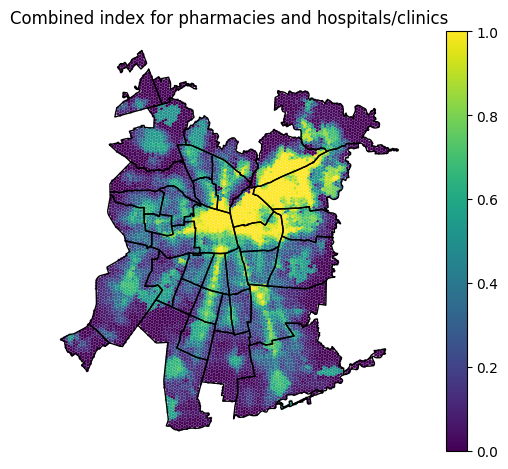

In [43]:
ax = acc.visualize.choropleth("total", legend=True)
ax.set_axis_off()
ax.set_title("Combined index for pharmacies and hospitals/clinics")

plt.tight_layout()

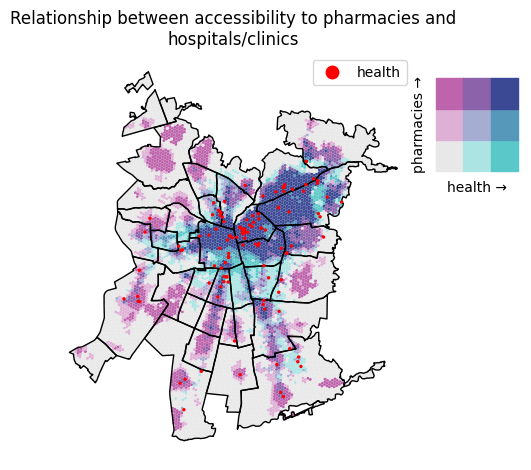

In [44]:
ax = acc.visualize.bivariate_choropleth(
    "pharmacies",
    "health",
    legend=True,
    overlay_cfg=xmin.OverlayConfig(
        show_amenities=["health"],
        amenities_kwds={
            "cmap": mcolors.ListedColormap(["red"])
        }
    )
)
ax.set_axis_off()
ax.set_title(
    "Relationship between accessibility to pharmacies and\nhospitals/clinics"
)

plt.tight_layout()

## Caso 3: grouping destinations within a single amenity type (`group_amenity_destinations`)

Finally, we will explore the grouping of destinations within a single amenity
type, once travel times have already been calculated.

The motivation behind this functionality is a difference between notions of
accessibility. Consider that we want to calculate accessibility to parks: each
park is represented as a set of points (entrances to the park), and the weight
of each point is equal to the area of the park divided by the number of entry
points the park has. The question now is: if a person can reach one entry point
of the park within a certain time limit, does this imply that they can access
the entire park, or only the entry point in question?

In the second case, it suffices to calculate `AccessibilityRatings` considering
each point as a possible destination (with its associated weight), but for the
first case, the travel time to the **entire park** (not just one entry point)
will be equal to the **lowest travel time** between all the entry points for
that park. We can use `group_amenity_destinations` to obtain these values,
modifying the original TTM.

### TTM calculation

In [45]:
ttm_ungrouped = xmin.TravelTimeMatrices.compute(
    origins=origins_full,
    amenities=[parks],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
)

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

We group the points according to `park_id`, a column that indicates the park to
which each point belongs.

In [46]:
ttm_grouped = deepcopy(ttm_ungrouped)
ttm_grouped.group_amenity_destinations("parks", "park_id")

### Index calculation

In [47]:
parks_index_function = TwoStepFca(
    threshold=20,
    desired_ratio=1,
)

In [48]:
acc_ungrouped = xmin.AccessibilityRatings.compute(
    ttm_ungrouped,
    index_function=parks_index_function
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
acc_grouped = xmin.AccessibilityRatings.compute(
    ttm_grouped,
    index_function=parks_index_function
)

Calculando índices para cada necesidad...


  0%|          | 0/1 [00:00<?, ?it/s]

### Visualization

We can observe than, when grouping destinations by park, access is "leveled" for all origins accessing any entry point within the park. Instead of origins closer to the park (that access multiple entry points) having a better score, all origins now have the same level of access.

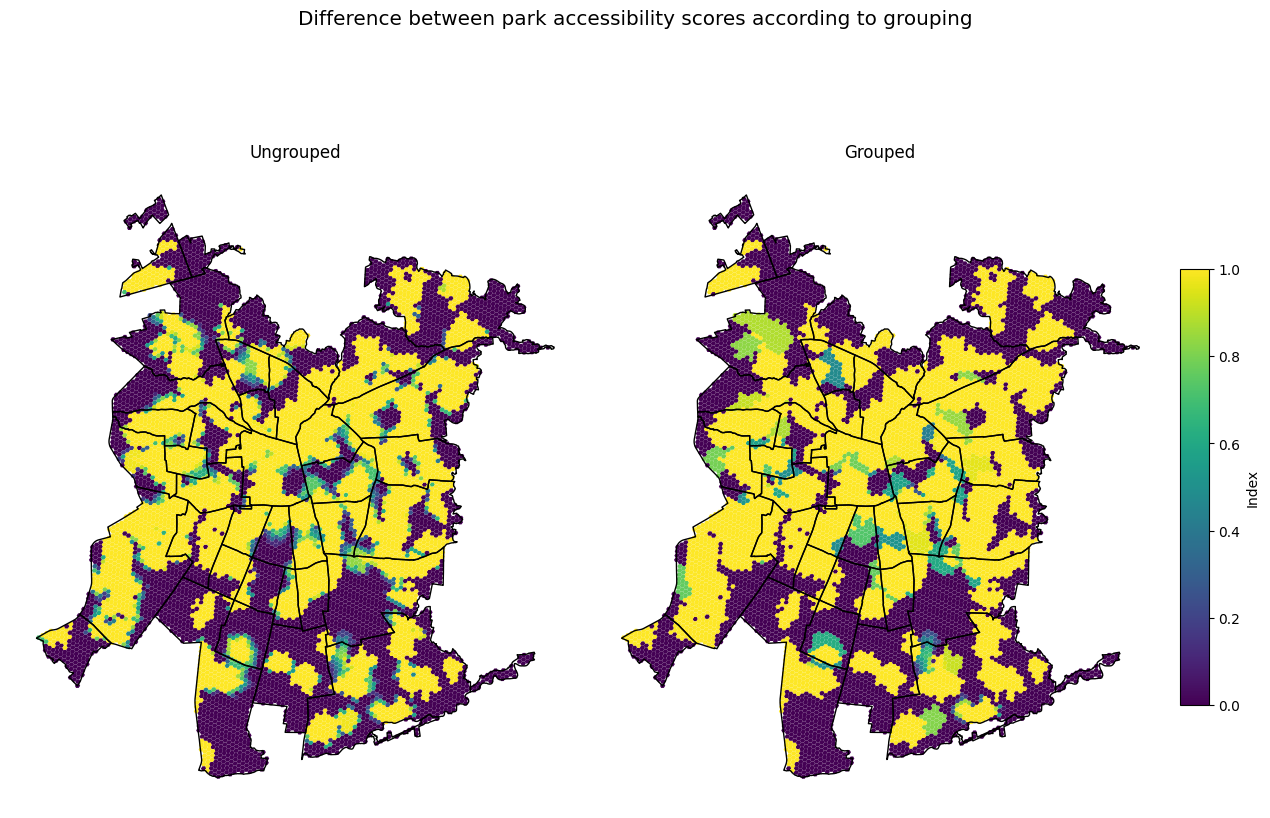

In [51]:
fig = plt.figure(figsize=(2 * 6.4, 2 * 4.8))
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_ungrouped = fig.add_subplot(gs[0:4, 0])
ax_grouped = fig.add_subplot(gs[0:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

for ax, acc, title in zip(
    (ax_ungrouped, ax_grouped),
    (acc_ungrouped, acc_grouped),
    ("Ungrouped", "Grouped")
):
    acc.visualize.choropleth("parks", ax=ax)
    ax.set_axis_off()
    ax.set_title(title)

cbar = plt.cm.ScalarMappable(cmap="viridis")
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Index")

fig.suptitle(
    "Difference between park accessibility scores according to grouping",
    fontsize="x-large",
)

plt.tight_layout()